# Battery Report

Analysis of one or more CarbonShift solver battery runs.

Configure `RESULT_CSVS` in the next cell to point at the `battery_results_*.csv`
files you want to analyse.  All files are merged into a single DataFrame; a
`battery_id` column is added automatically from the file name.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams["figure.dpi"] = 96
plt.style.use("seaborn-v0_8-whitegrid")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Configure these paths (absolute or relative to the notebook location) ──────

RESULT_CSVS: list[str | Path] = [
    "results/battery_results_default.csv",
]

# ────────────────────────────────────────────────────────────────────────────────

# Metrics to plot
METRICS: list[dict] = [
    {
        "col": "solver_time_ms_avg",
        "label": "Solver time (ms avg)",
        "color": "tab:blue",
    },
    {
        "col": "total_carbon_cost",
        "label": "Total carbon cost",
        "color": "tab:green",
    },
    {
        "col": "final_global_error",
        "label": "Final global error",
        "color": "tab:red",
    },
    {
        "col": "avg_global_error_per_slot",
        "label": "Avg global error / slot",
        "color": "tab:orange",
    },
    {
        "col": "carbon_cost_saving_vs_baseline_pct",
        "label": "Carbon saving vs baseline (%)",
        "color": "tab:purple",
    },
    {
        "col": "total_rollbacks",
        "label": "Total rollbacks (Rust only)",
        "color": "tab:brown",
    },
    {
        "col": "max_consecutive_rollbacks",
        "label": "Max consecutive rollbacks",
        "color": "tab:pink",
    },
    {
        "col": "peak_concurrent_workers",
        "label": "Peak concurrent workers",
        "color": "tab:gray",
    },
    {
        "col": "avg_concurrent_workers",
        "label": "Avg concurrent workers",
        "color": "tab:olive",
    },
]

MODE_STYLE: dict = {
    "greedy_fallback": {
        "linestyle": "-",
        "marker": "o",
    },
    "relaxed_retry": {
        "linestyle": "--",
        "marker": "s",
    },
}

BACKEND_COLOR: dict = {
    "python": {
        "greedy_fallback": "tab:blue",
        "relaxed_retry": "tab:cyan",
    },
    "rust": {
        "greedy_fallback": "tab:orange",
        "relaxed_retry": "tab:red",
    },
}

In [2]:
_nb_dir = Path(__file__) if "__file__" in dir() else Path.cwd()

frames = []

for p in RESULT_CSVS:
    p = Path(p) if not isinstance(p, Path) else p

    if not p.is_absolute():
        p = (_nb_dir / p).resolve()

    if not p.exists():
        raise FileNotFoundError(f"Results CSV not found: {p}")

    _df = pd.read_csv(p)

    # Derive battery_id from file stem:
    # battery_results_<id>.csv or battery_results.csv
    stem = p.stem  # e.g. "battery_results_run1"

    bid = stem.removeprefix("battery_results").lstrip("_") or "unnamed"

    _df.insert(0, "battery_id", bid)

    frames.append(_df)

df = pd.concat(frames, ignore_index=True)

df["batch_size"] = df["batch_size"].astype(int)

# Rollback columns may be absent in CSVs produced before the feature was added.
for _rb_col in (
    "total_rollbacks",
    "max_consecutive_rollbacks",
    "peak_concurrent_workers",
    "avg_concurrent_workers",
):
    if _rb_col not in df.columns:
        df[_rb_col] = 0

df["total_rollbacks"] = (
    df["total_rollbacks"]
    .fillna(0)
    .astype(int)
)

df["max_consecutive_rollbacks"] = (
    df["max_consecutive_rollbacks"]
    .fillna(0)
    .astype(int)
)

print(f"Loaded {len(df)} rows from {len(frames)} CSV file(s).")
print(f"Batteries   : {sorted(df['battery_id'].unique())}")
print(f"Scenarios   : {sorted(df['scenario_id'].unique())}")
print(f"Backends    : {sorted(df['backend'].unique())}")
print(f"Modes       : {sorted(df['infeasibility_mode'].unique())}")
print(f"Batch sizes : {sorted(df['batch_size'].unique())}")

df

Loaded 70 rows from 1 CSV file(s).
Batteries   : ['default']
Scenarios   : ['high_load_105', 'high_load_92', 'low_load_2028', 'low_load_2030', 'medium_load_2028', 'medium_load_38', 'xhigh_load_120']
Backends    : ['rust']
Modes       : ['greedy_fallback', 'relaxed_retry']
Batch sizes : [np.int64(1), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]


,battery_id,scenario_id,backend,batch_size,infeasibility_mode,solver_time_ms_avg,total_carbon_cost,final_global_error,avg_global_error_per_slot,requests_assigned_with_greedy_fallback,requests_assigned_with_relaxed_retry,total_rollbacks,max_consecutive_rollbacks,baseline_total_carbon_cost,carbon_cost_saving_vs_baseline_pct,peak_concurrent_workers,avg_concurrent_workers
0,default,low_load_2028,rust,1,greedy_fallback,2.8795,1123.8117,3.9989,3.9988,0,0,50,1,4841.5281,76.7881,20,8.9376
1,default,low_load_2028,rust,4,greedy_fallback,3.7792,1083.8206,3.9972,4.0017,0,0,160,3,4841.5281,77.6141,10,3.1365
2,default,low_load_2028,rust,6,greedy_fallback,9.5319,1202.5918,3.9621,3.9547,0,0,126,4,4841.5281,75.1609,6,2.0778
3,default,low_load_2028,rust,8,greedy_fallback,15.7806,1212.6655,3.9586,3.9456,0,0,77,3,4841.5281,74.9528,5,1.6538
4,default,low_load_2028,rust,10,greedy_fallback,22.5137,1247.1704,3.9323,3.9196,0,0,51,2,4841.5281,74.2401,4,1.4046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,default,xhigh_load_120,rust,1,relaxed_retry,0.9560,3772.0576,3.9940,3.9942,0,28,19,1,28601.7519,86.8118,20,17.7700
66,default,xhigh_load_120,rust,4,relaxed_retry,6.5951,6812.9703,3.9967,4.0006,0,71,277,4,28601.7519,76.1799,20,14.1136
67,default,xhigh_load_120,rust,6,relaxed_retry,17.9293,7357.0018,3.9764,3.9720,0,1532,640,4,28601.7519,74.2778,20,10.9944
68,default,xhigh_load_120,rust,8,relaxed_retry,27.3523,8256.6191,3.9349,3.9285,0,1759,735,4,28601.7519,71.1325,20,8.8892


## Execution timings

Wall-clock time per scenario and total battery run time, read from
`battery_timings_*.csv` files that mirror the `RESULT_CSVS` list above.


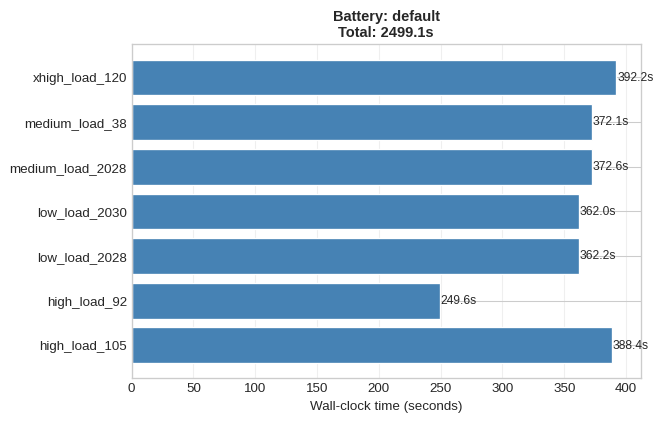


Per-battery totals:
  default: 2499.1s


In [3]:
# Derive timing CSV paths from RESULT_CSVS (battery_results_X.csv → battery_timings_X.csv)
timing_frames = []
for p in RESULT_CSVS:
    p = Path(p) if not isinstance(p, Path) else p
    if not p.is_absolute():
        p = (_nb_dir / p).resolve()
    stem = p.stem  # e.g. "battery_results_run1"
    bid = stem.removeprefix("battery_results").lstrip("_") or "unnamed"
    timing_path = p.parent / f"battery_timings{('_' + bid) if bid != 'unnamed' else ''}.csv"
    if not timing_path.exists():
        print(f"WARNING: timing file not found: {timing_path}")
        continue
    _t = pd.read_csv(timing_path)
    _t.insert(0, "battery_id", bid)
    timing_frames.append(_t)

if not timing_frames:
    print("No timing files found – run the battery first to generate timings.")
else:
    tdf = pd.concat(timing_frames, ignore_index=True)

    # Separate per-scenario rows from the battery total
    scenario_times = tdf[tdf["scenario_id"] != "__battery_total__"].copy()
    battery_totals = tdf[tdf["scenario_id"] == "__battery_total__"].copy()

    battery_ids = scenario_times["battery_id"].unique().tolist()
    n_batteries = len(battery_ids)

    fig, axes = plt.subplots(1, n_batteries, figsize=(max(7, 5 * n_batteries), 4.5), squeeze=False)

    for ax, bid in zip(axes[0], battery_ids):
        sub = scenario_times[scenario_times["battery_id"] == bid].sort_values("scenario_id")
        total_row = battery_totals[battery_totals["battery_id"] == bid]
        total_s = float(total_row["elapsed_seconds"].iloc[0]) if not total_row.empty else sub["elapsed_seconds"].sum()

        bars = ax.barh(sub["scenario_id"], sub["elapsed_seconds"], color="steelblue", edgecolor="white")
        for bar, val in zip(bars, sub["elapsed_seconds"]):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}s", va="center", fontsize=9)

        ax.set_xlabel("Wall-clock time (seconds)")
        ax.set_title(
            f"Battery: {bid}\nTotal: {total_s:.1f}s",
            fontsize=11, fontweight="bold",
        )
        ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nPer-battery totals:")
    for bid in battery_ids:
        total_row = battery_totals[battery_totals["battery_id"] == bid]
        if not total_row.empty:
            print(f"  {bid}: {float(total_row['elapsed_seconds'].iloc[0]):.1f}s")


## Per-scenario metrics

One figure per scenario.  Each figure shows all metrics; lines are split by
`(backend, infeasibility_mode)` combination.


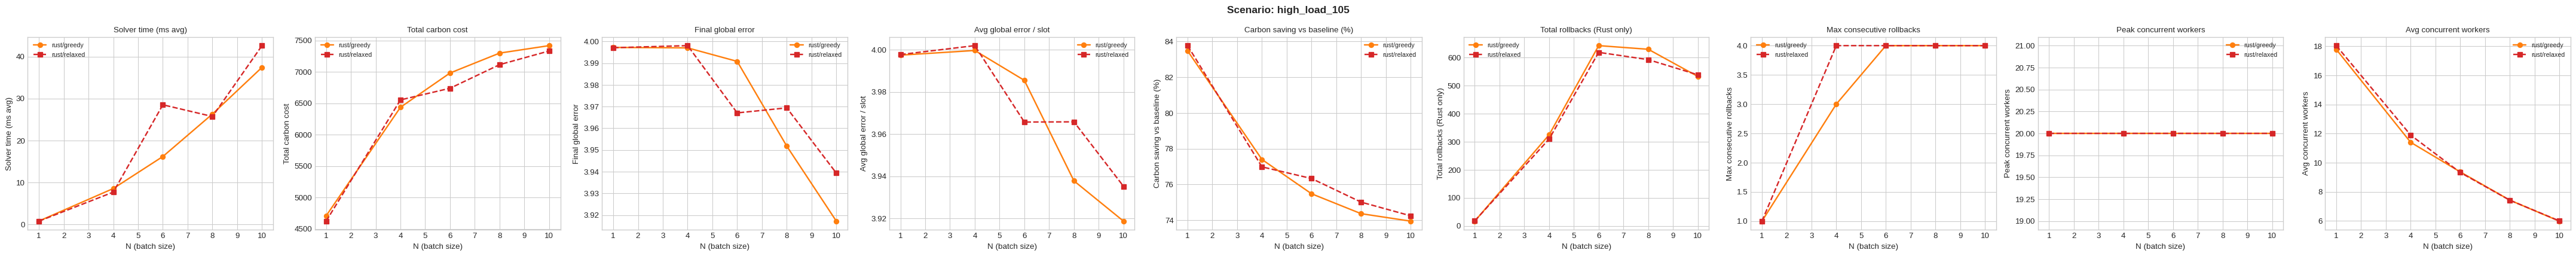

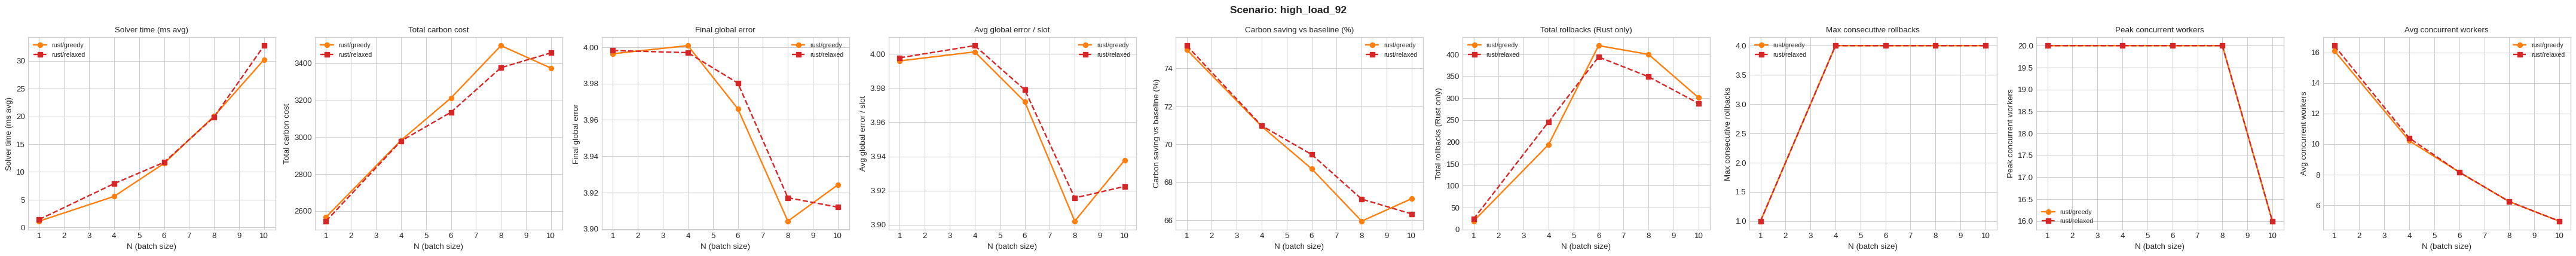

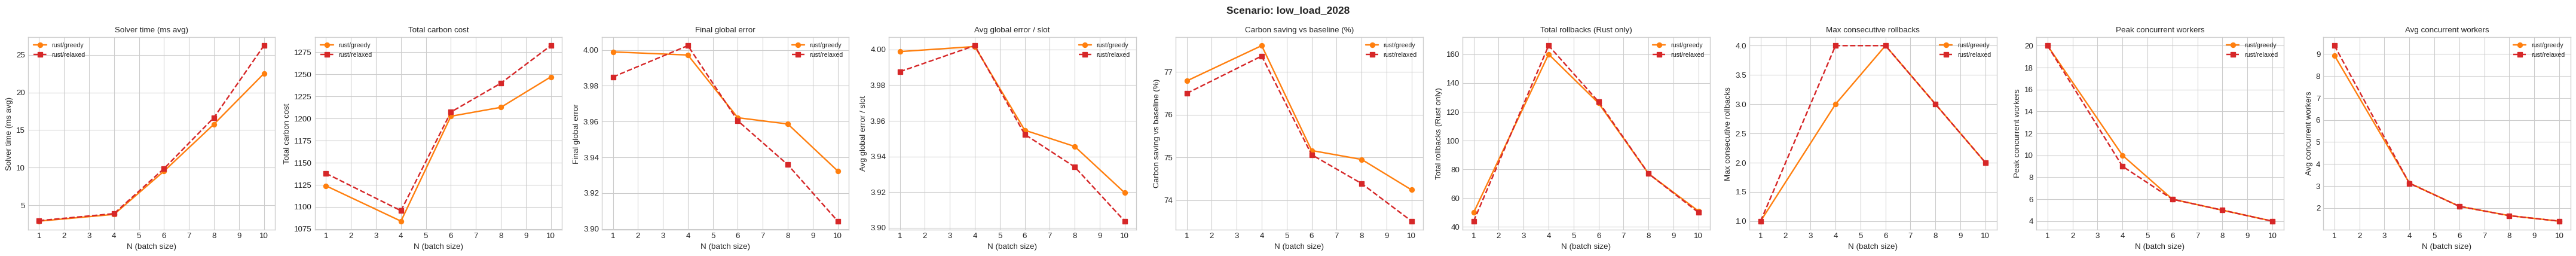

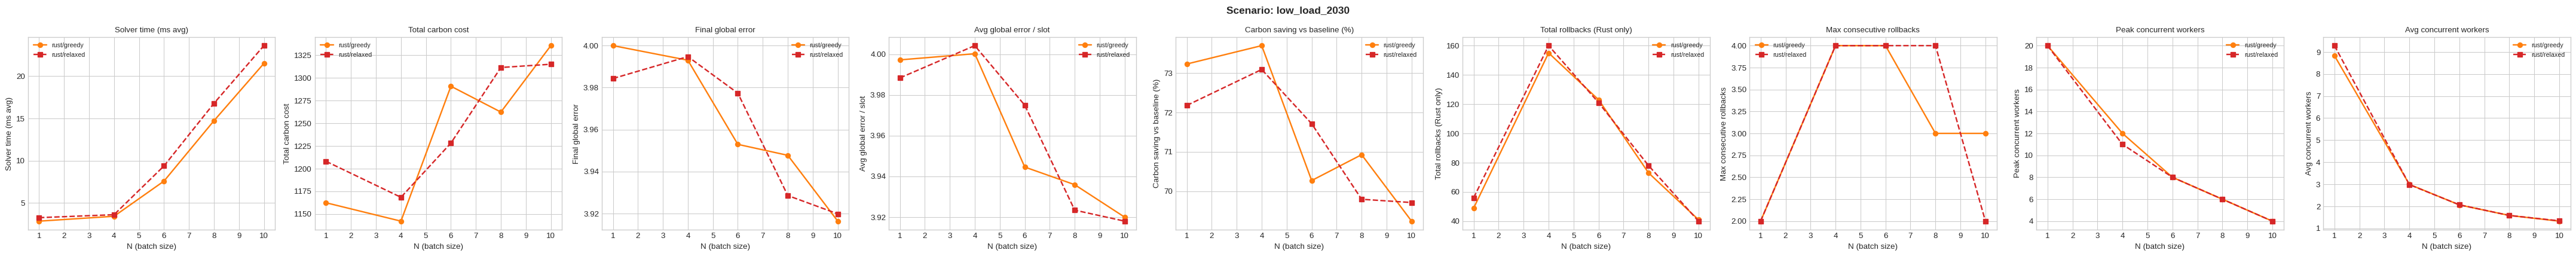

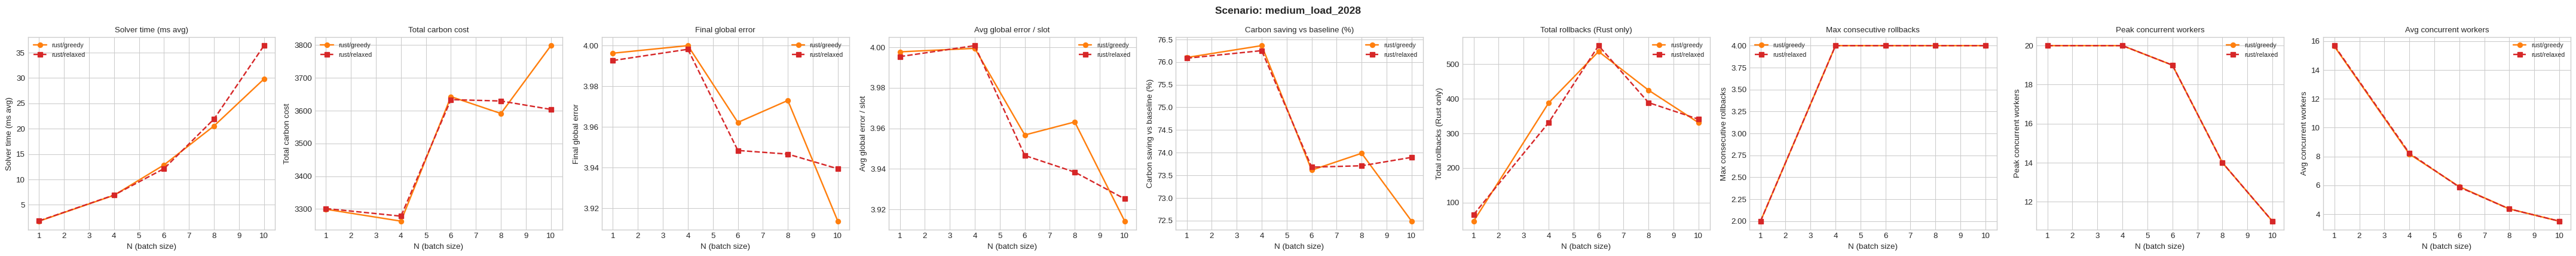

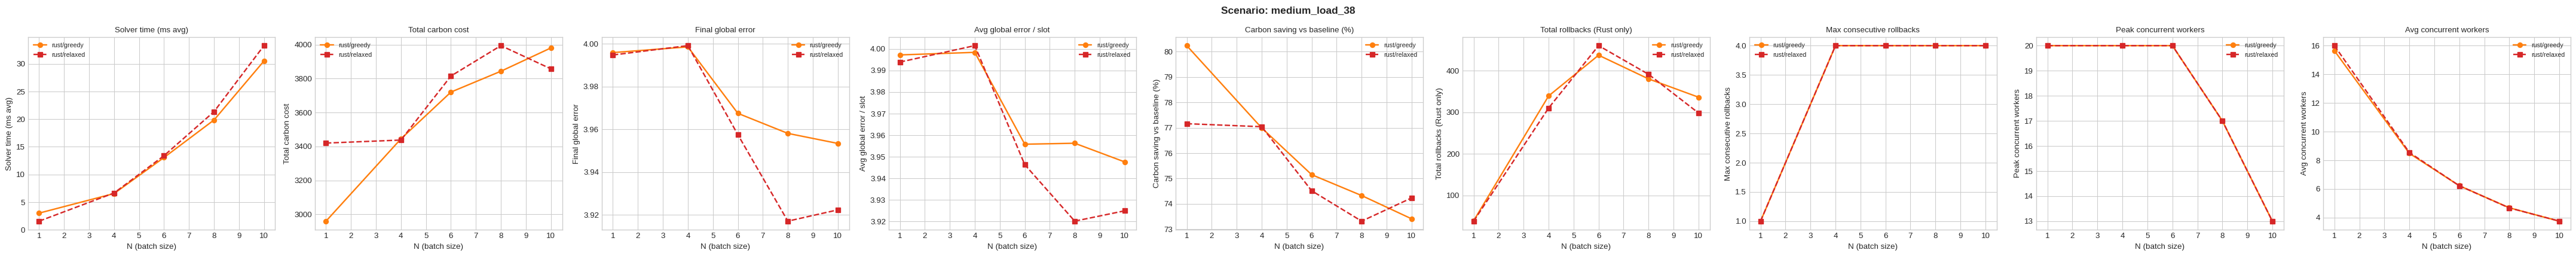

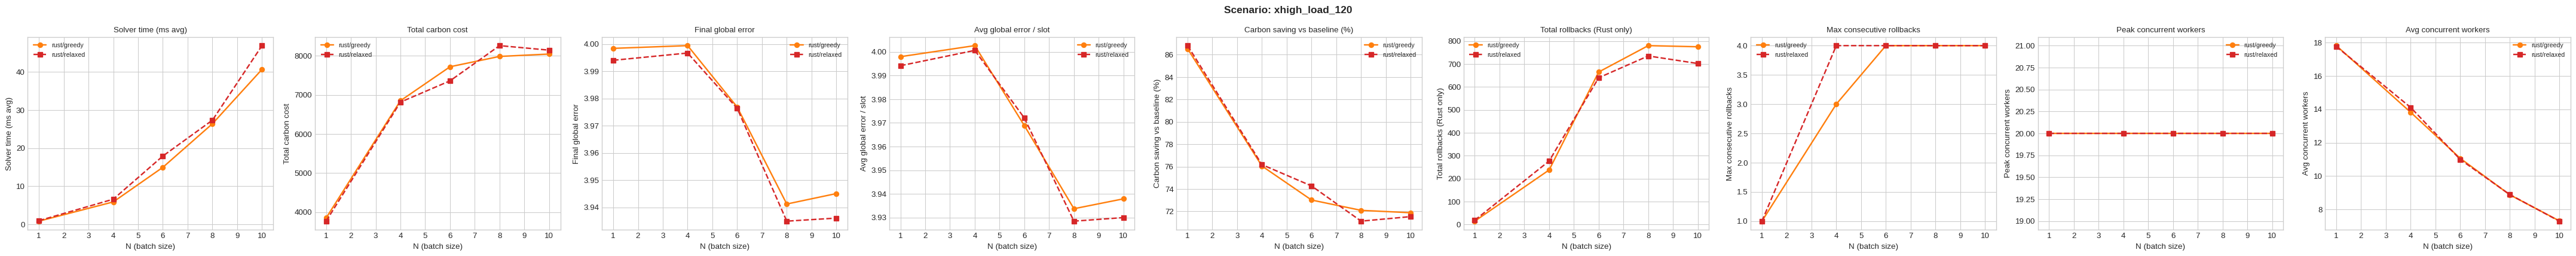

In [4]:
def _series_label(backend: str, mode: str) -> str:
    mode_short = "greedy" if mode == "greedy_fallback" else "relaxed"
    return f"{backend}/{mode_short}"

def _series_style(backend: str, mode: str) -> dict:
    color = BACKEND_COLOR.get(backend, {}).get(mode, "gray")
    style = MODE_STYLE.get(mode, {})
    return {"color": color, **style}

scenarios = sorted(df["scenario_id"].unique())
combos = sorted(
    df[["backend", "infeasibility_mode"]].drop_duplicates().itertuples(index=False, name=None)
)
n_metrics = len(METRICS)

for sid in scenarios:
    s_df = df[df["scenario_id"] == sid].sort_values("batch_size")
    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 4.5))
    if n_metrics == 1:
        axes = [axes]
    fig.suptitle(f"Scenario: {sid}", fontsize=13, fontweight="bold")

    for ax, m in zip(axes, METRICS):
        for backend, mode in combos:
            sub = s_df[(s_df["backend"] == backend) & (s_df["infeasibility_mode"] == mode)]
            if sub.empty:
                continue
            label = _series_label(backend, mode)
            style = _series_style(backend, mode)
            ax.plot(sub["batch_size"], sub[m["col"]], label=label, linewidth=1.8, **style)
        ax.set_xlabel("N (batch size)")
        ax.set_ylabel(m["label"])
        ax.set_title(m["label"], fontsize=10)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.legend(fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()


## All scenarios on one chart

Each metric is shown in a single figure with one subplot per `(backend, infeasibility_mode)`
combination.  All scenarios appear as separate lines to allow direct comparison.


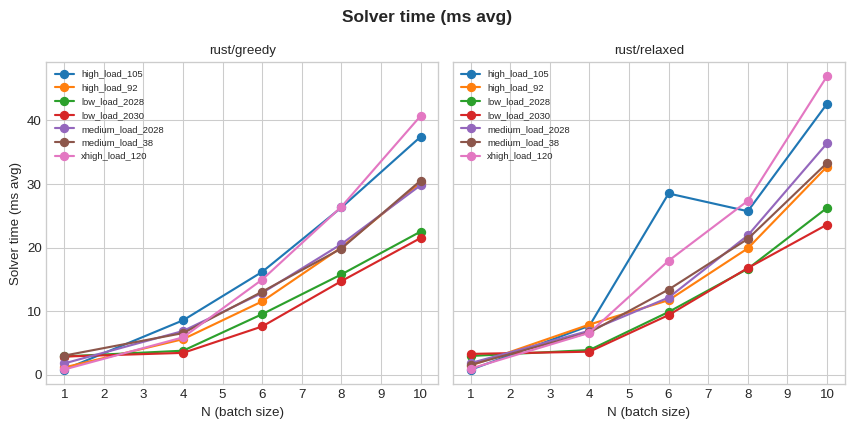

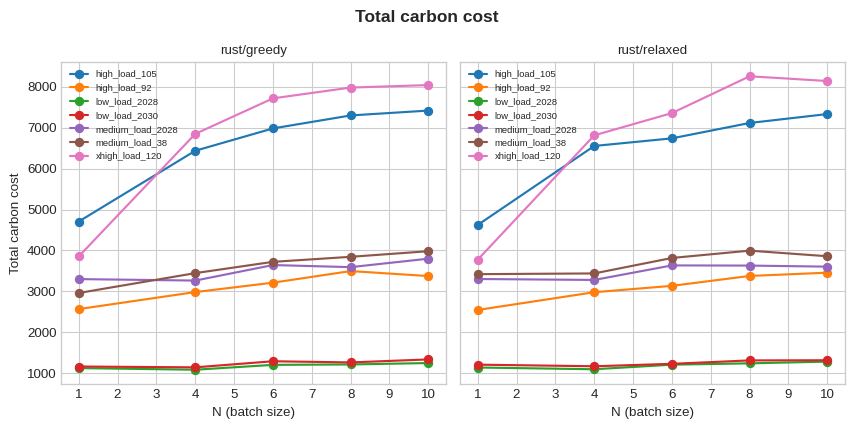

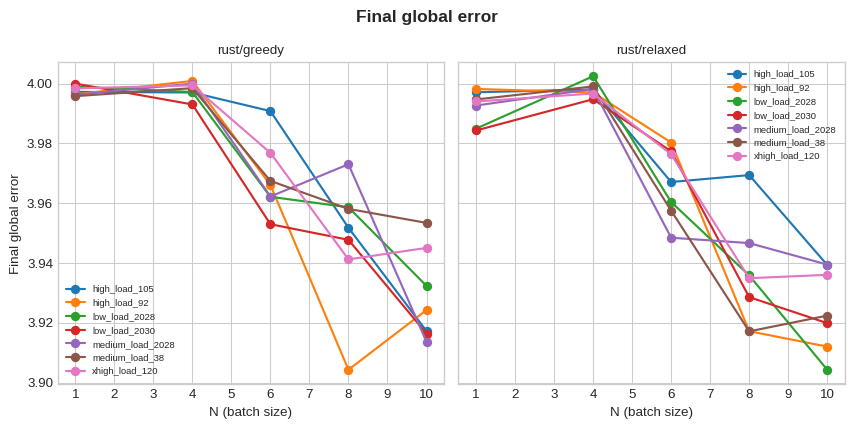

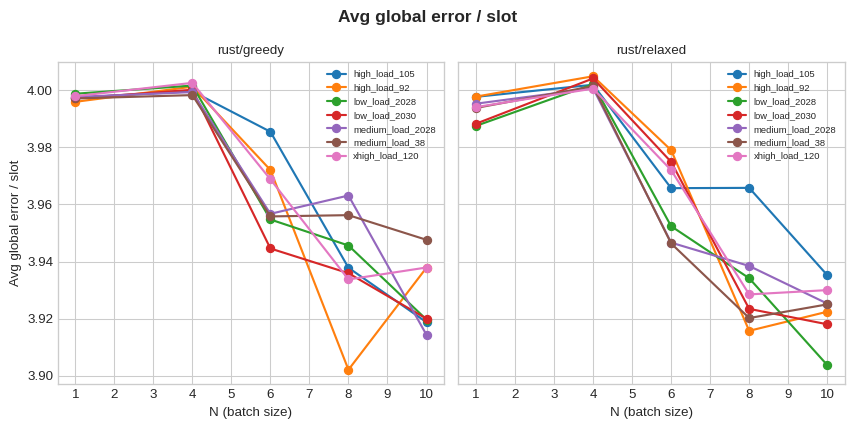

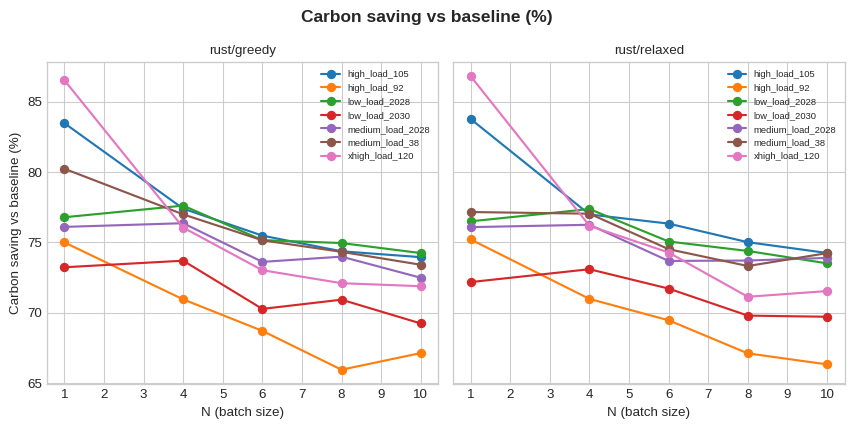

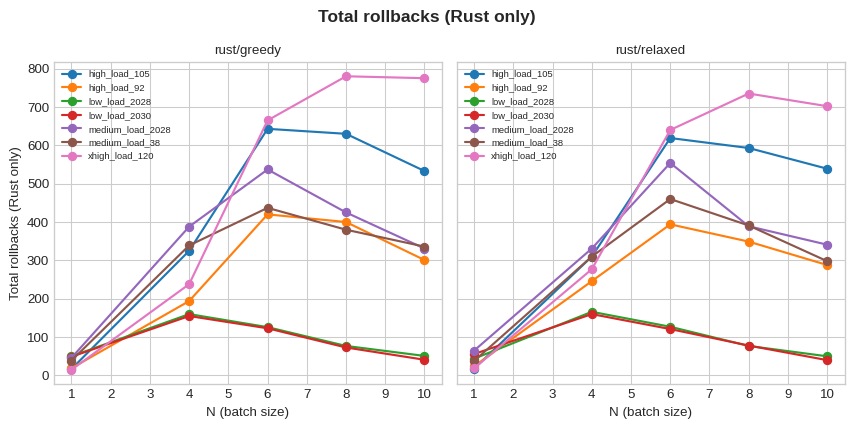

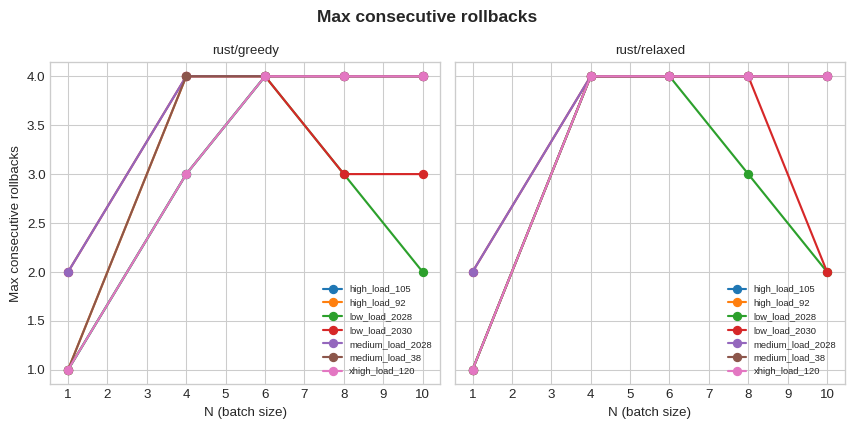

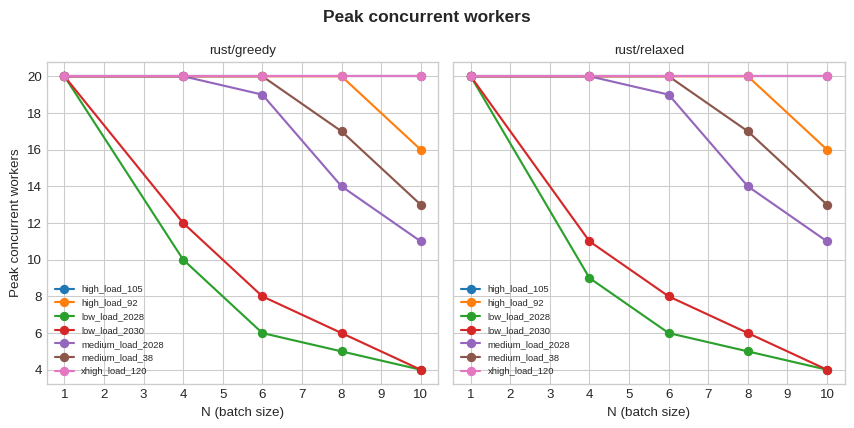

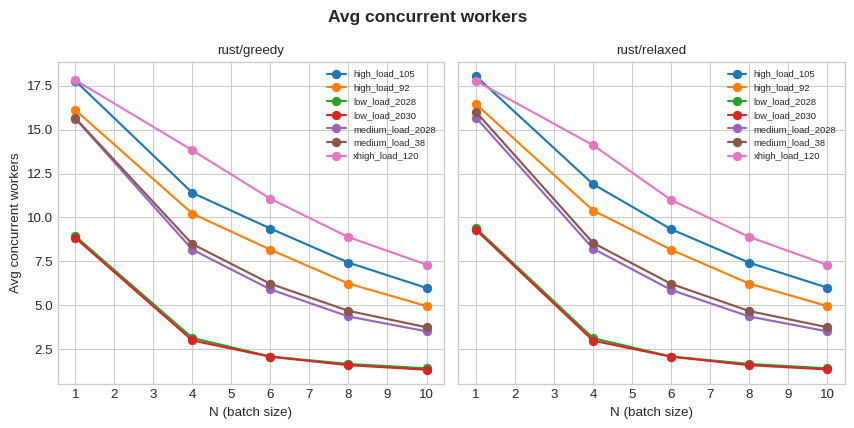

In [5]:
fig_w = max(6, 4.5 * len(combos))
for m in METRICS:
    fig, axes = plt.subplots(1, len(combos), figsize=(fig_w, 4.5), sharey=True)
    if len(combos) == 1:
        axes = [axes]
    fig.suptitle(m["label"], fontsize=13, fontweight="bold")

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    sid_color = {sid: colors[i % len(colors)] for i, sid in enumerate(scenarios)}

    for ax, (backend, mode) in zip(axes, combos):
        ax.set_title(_series_label(backend, mode), fontsize=10)
        ax.set_xlabel("N (batch size)")
        if ax is axes[0]:
            ax.set_ylabel(m["label"])
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

        for sid in scenarios:
            sub = df[
                (df["scenario_id"] == sid) &
                (df["backend"] == backend) &
                (df["infeasibility_mode"] == mode)
            ].sort_values("batch_size")
            if sub.empty:
                continue
            ax.plot(sub["batch_size"], sub[m["col"]],
                    marker="o", linewidth=1.6, color=sid_color[sid],
                    label=sid)

        ax.legend(fontsize=7, loc="best")

    plt.tight_layout()
    plt.show()


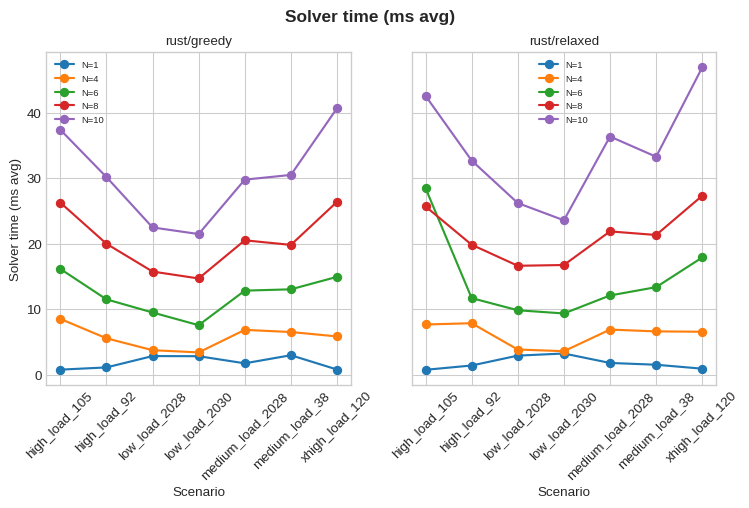

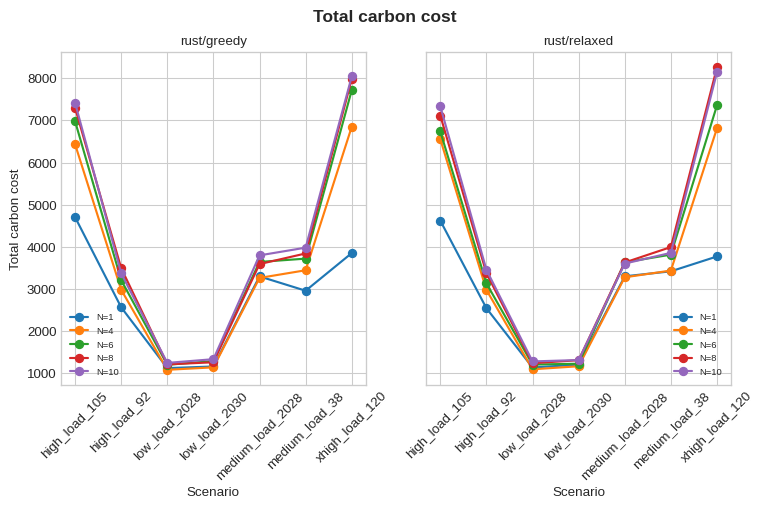

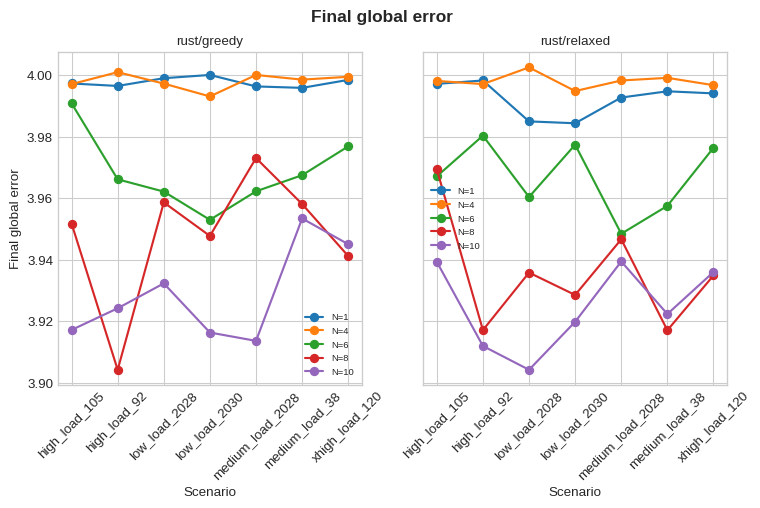

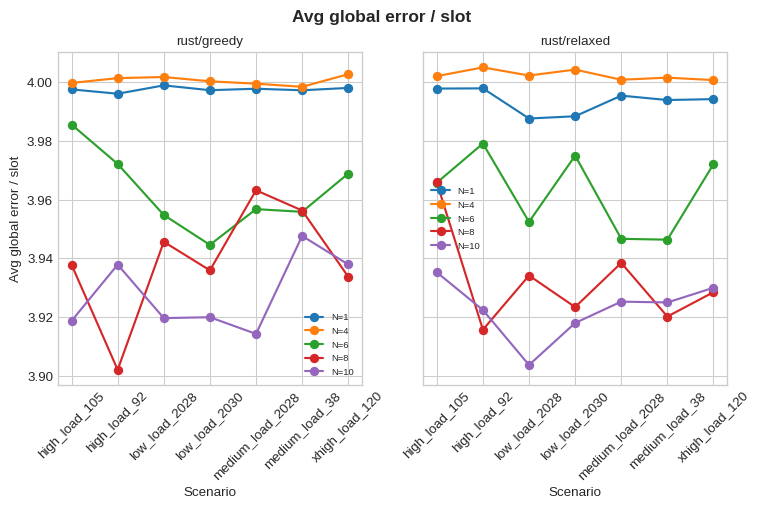

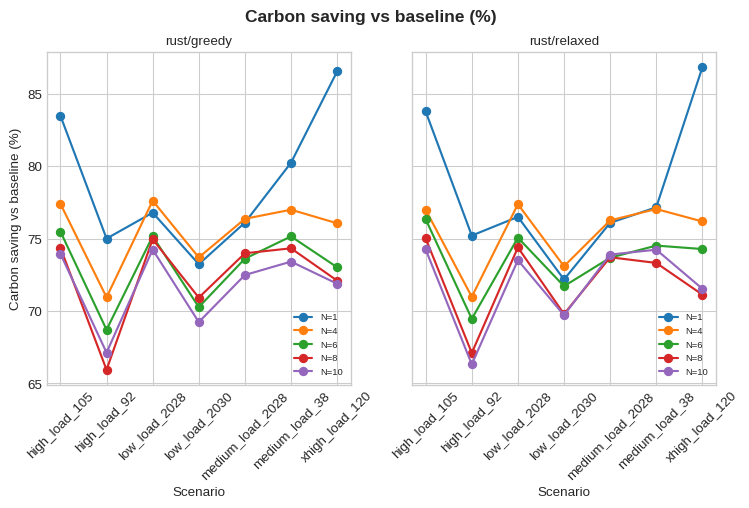

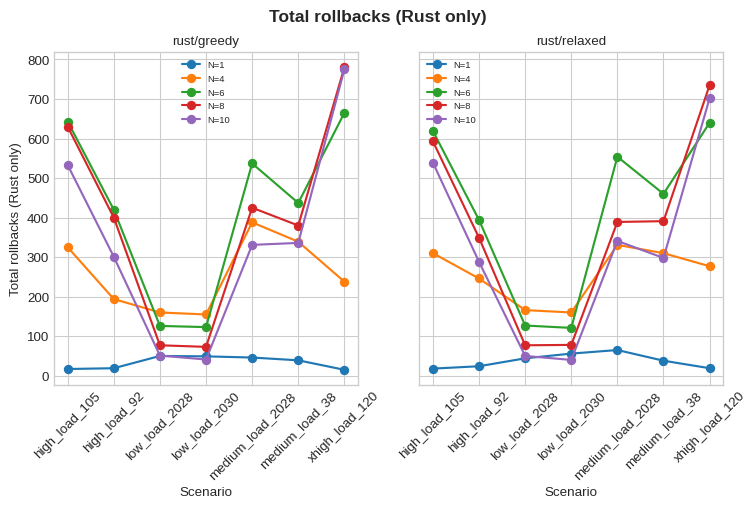

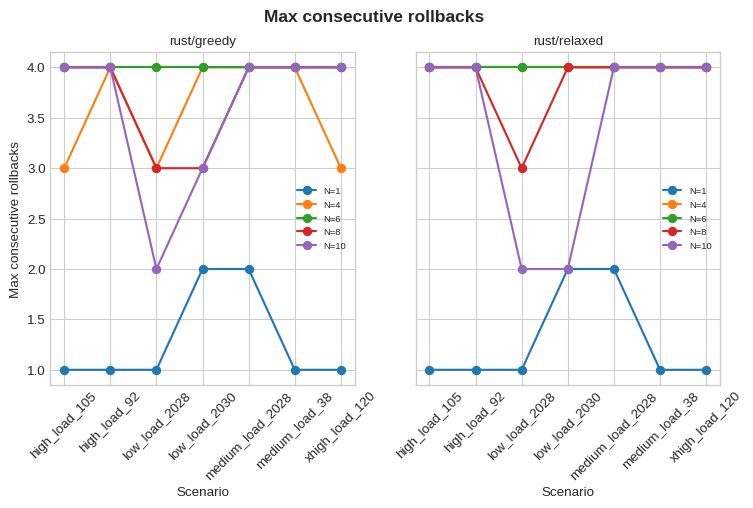

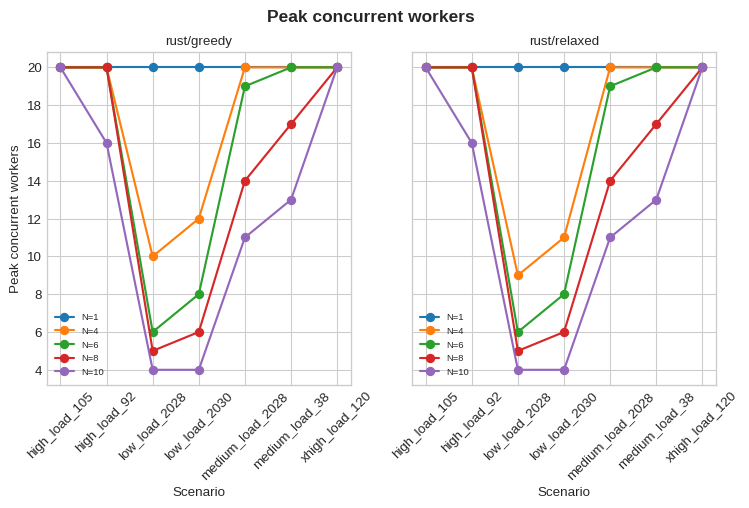

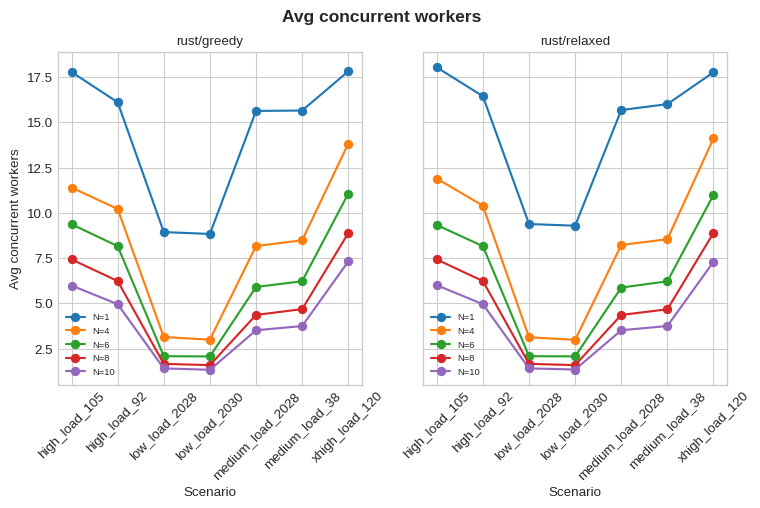

In [6]:
fig_w = max(6, 4.5 * len(combos))

fig_w = max(6, 4.5 * len(combos))

for m in METRICS:

    fig, axes = plt.subplots(
        1,
        len(combos),
        figsize=(fig_w, 4.5),
        sharey=True
    )

    if len(combos) == 1:
        axes = [axes]

    fig.suptitle(m["label"], fontsize=13, fontweight="bold")

    for ax, (backend, mode) in zip(axes, combos):

 
       ax.set_title(_series_label(backend, mode), fontsize=10)
       ax.set_xlabel("Scenario")
       if ax is axes[0]:
           ax.set_ylabel(m["label"])
    
       # dati del pannello corrente
       panel_df = df[
           (df["backend"] == backend) &
           (df["infeasibility_mode"] == mode)
       ]
    
       batch_sizes = sorted(panel_df["batch_size"].unique())
    
       colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
       bs_color = {
           bs: colors[i % len(colors)]
           for i, bs in enumerate(batch_sizes)
       }
    
       for bs in batch_sizes:
           sub = (
               panel_df[panel_df["batch_size"] == bs]
               .set_index("scenario_id")
               .reindex(scenarios)  # mantiene l'ordine desiderato
           )
    
           ax.plot(
               scenarios,
               sub[m["col"]],
               marker="o",
               linewidth=1.6,
               color=bs_color[bs],
               label=f"N={bs}"
           )
    
       ax.legend(fontsize=7, loc="best")
    
       # migliora la leggibilità se gli scenari hanno nomi lunghi
       ax.tick_params(axis="x", rotation=45)

    # plt.tight_layout()
    # plt.show()


## Aggregate statistics across all scenarios

Min / mean / max of each metric, grouped by `(backend, infeasibility_mode, batch_size)`.


In [7]:
metric_cols = [m["col"] for m in METRICS]
agg = (
    df.groupby(["backend", "infeasibility_mode", "batch_size"])[metric_cols]
    .agg(["min", "mean", "max"])
    .round(4)
)
agg


solver_time_ms_avg                  \
                                                     min    mean     max   
backend infeasibility_mode batch_size                                      
rust    greedy_fallback    1                      0.8098  1.9017  3.0098   
                           4                      3.4371  5.8113  8.5577   
                           6                      7.5948 12.2510 16.1848   
                           8                     14.7264 20.5215 26.4162   
                           10                    21.5017 30.3828 40.7010   
        relaxed_retry      1                      0.7861  1.8282  3.2733   
                           4                      3.6238  6.1805  7.8932   
                           6                      9.3845 14.7065 28.5031   
                           8                     16.6605 21.3786 27.3523   
                           10                    23.6028 34.5409 46.9383   

                                      total_carbon_cost                      \
                                                    min      mean       max   
backend infeasibility_mode batch_size                                         
rust    greedy_fallback    1                  1123.8117 2809.7603 4705.4307   
                           4                  1083.8206 3599.9813 6848.5272   
                           6                  1202.5918 3966.6992 7716.6972   
                           8                  1212.6655 4097.8107 7980.5383   
                           10                 1247.1704 4170.7706 8041.6809   
        relaxed_retry      1                  1137.8725 2857.9384 4621.8332   
                           4                  1095.6201 3617.7852 6812.9703   
                           6                  1207.3474 3873.5302 7357.0018   
                           8                  1239.9812 4131.8576 8256.6191   
                           10                 1282.5416 4141.2604 8140.6305   

                                      final_global_error                \
                                                     min   mean    max   
backend infeasibility_mode batch_size                                    
rust    greedy_fallback    1                      3.9958 3.9976 4.0000   
                           4                      3.9930 3.9980 4.0009   
                           6                      3.9530 3.9684 3.9908   
                           8                      3.9043 3.9478 3.9730   
                           10                     3.9137 3.9289 3.9534   
        relaxed_retry      1                      3.9843 3.9923 3.9982   
                           4                      3.9948 3.9980 4.0025   
                           6                      3.9484 3.9668 3.9803   
                           8                      3.9171 3.9357 3.9694   
                           10                     3.9043 3.9248 3.9394   

                                      avg_global_error_per_slot                \
                                                            min   mean    max   
backend infeasibility_mode batch_size                                           
rust    greedy_fallback    1                             3.9960 3.9975 3.9988   
                           4                             3.9984 4.0005 4.0026   
                           6                             3.9446 3.9626 3.9855   
                           8                             3.9021 3.9392 3.9631   
                           10                            3.9143 3.9280 3.9476   
        relaxed_retry      1                             3.9876 3.9935 3.9978   
                           4                             4.0006 4.0023 4.0050   
                           6                             3.9463 3.9624 3.9790   
                           8                             3.9157 3.9323 3.9658   
                           10                            3.9037 3.9228 3.9352   

    

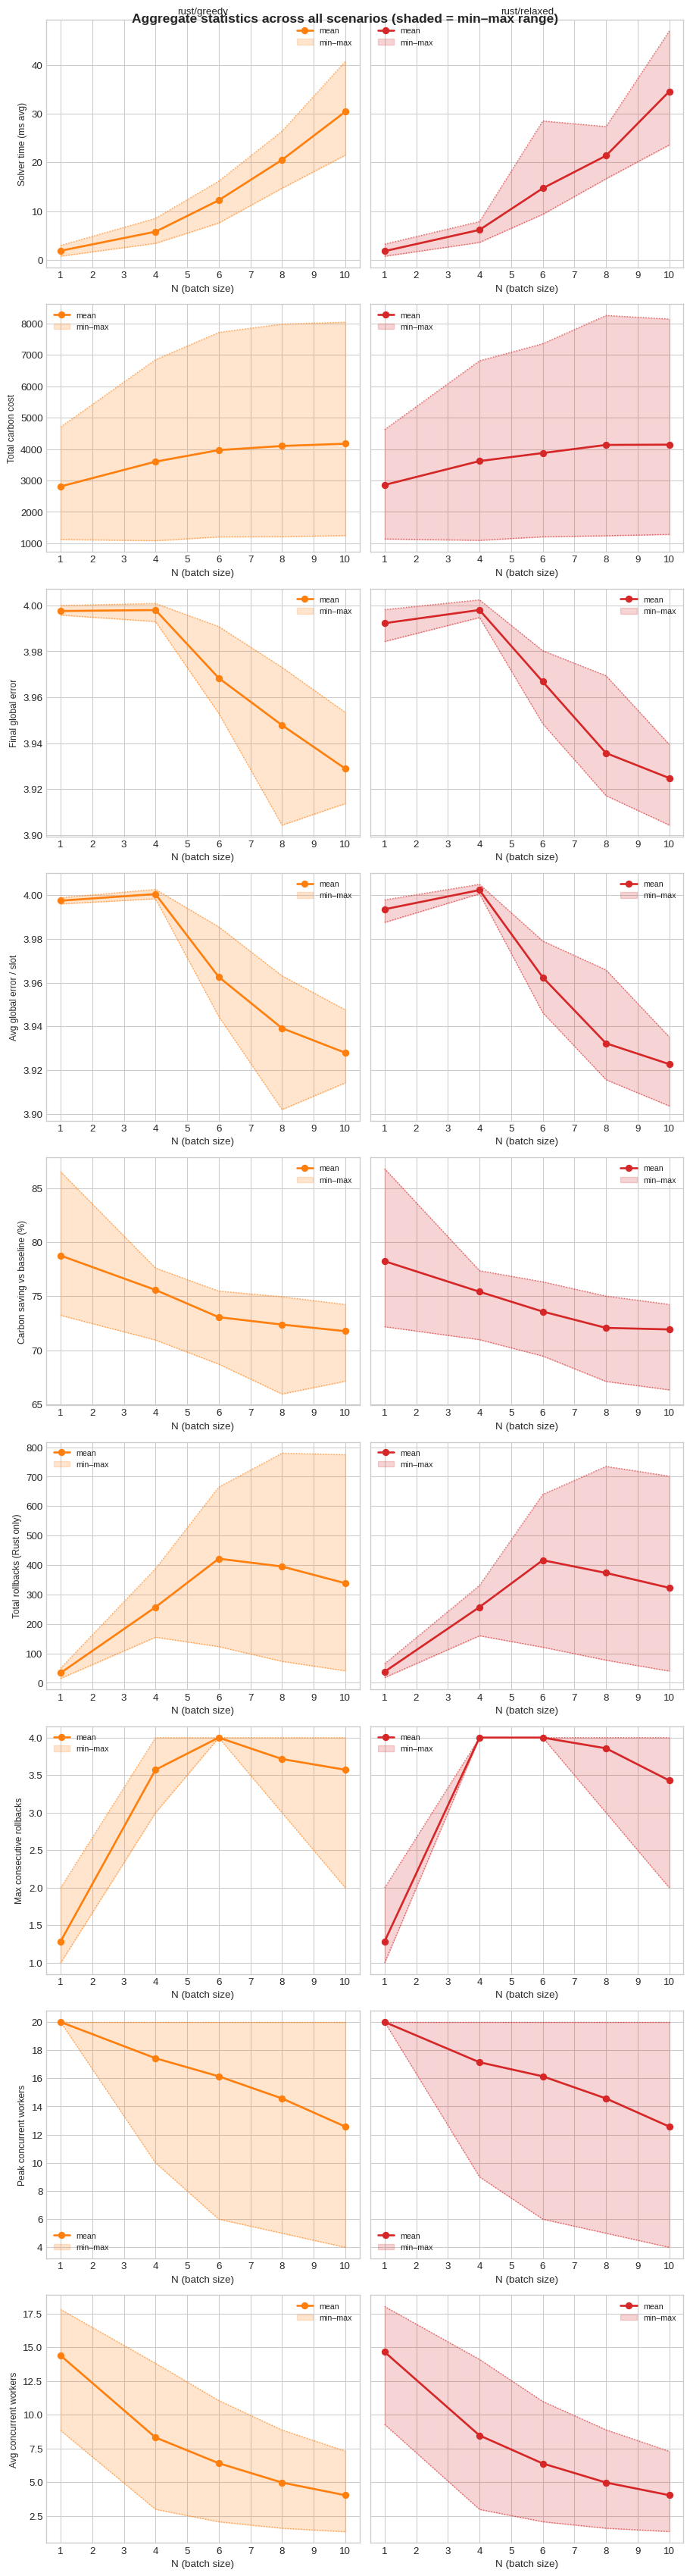

In [8]:
combos_sorted = sorted(combos)
fig_rows = len(METRICS)
fig_cols = len(combos_sorted)

fig, axes = plt.subplots(
    fig_rows, fig_cols,
    figsize=(4.8 * fig_cols, 4.0 * fig_rows),
    squeeze=False,
    sharey='row',
)
fig.suptitle("Aggregate statistics across all scenarios (shaded = min–max range)\n", fontsize=13, fontweight="bold")

for row, m in enumerate(METRICS):
    for col, (backend, mode) in enumerate(combos_sorted):
        ax = axes[row][col]
        sub = df[(df["backend"] == backend) & (df["infeasibility_mode"] == mode)]
        if sub.empty:
            ax.set_visible(False)
            continue
        grp = sub.groupby("batch_size")[m["col"]].agg(["min", "mean", "max"]).reset_index().sort_values("batch_size")
        xs = grp["batch_size"].values
        color = BACKEND_COLOR.get(backend, {}).get(mode, "gray")
        ax.plot(xs, grp["mean"], marker="o", linewidth=2.0, color=color, label="mean")
        ax.fill_between(xs, grp["min"], grp["max"], alpha=0.2, color=color, label="min–max")
        ax.plot(xs, grp["min"], linestyle=":", linewidth=1.0, color=color, alpha=0.7)
        ax.plot(xs, grp["max"], linestyle=":", linewidth=1.0, color=color, alpha=0.7)
        if row == 0:
            ax.set_title(_series_label(backend, mode), fontsize=10)
        if col == 0:
            ax.set_ylabel(m["label"], fontsize=9)
        ax.set_xlabel("N (batch size)")
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()


In [9]:
# Flat min/max/avg table (all N combined per backend+mode)
overall = (
    df.groupby(["backend", "infeasibility_mode"])[metric_cols]
    .agg(["min", "mean", "max"])
    .round(4)
)
print("Overall min / mean / max across ALL scenarios and ALL N values:")
overall


Overall min / mean / max across ALL scenarios and ALL N values:


solver_time_ms_avg                  \
                                          min    mean     max   
backend infeasibility_mode                                      
rust    greedy_fallback                0.8098 14.1737 40.7010   
        relaxed_retry                  0.7861 15.7270 46.9383   

                           total_carbon_cost                      \
                                         min      mean       max   
backend infeasibility_mode                                         
rust    greedy_fallback            1083.8206 3729.0044 8041.6809   
        relaxed_retry              1095.6201 3724.4744 8256.6191   

                           final_global_error                \
                                          min   mean    max   
backend infeasibility_mode                                    
rust    greedy_fallback                3.9043 3.9681 4.0009   
        relaxed_retry                  3.9043 3.9635 4.0025   

                           avg_global_error_per_slot                \
                                                 min   mean    max   
backend infeasibility_mode                                           
rust    greedy_fallback                       3.9021 3.9656 4.0026   
        relaxed_retry                         3.9037 3.9627 4.0050   

                           carbon_cost_saving_vs_baseline_pct                  \
                                                          min    mean     max   
backend infeasibility_mode                                                      
rust    greedy_fallback                               65.9447 74.3076 86.5311   
        relaxed_retry                                 66.3261 74.2450 86.8118   

                           total_rollbacks                \
                                       min     mean  max   
backend infeasibility_mode                                 
rust    greedy_fallback                 15 289.0857  780   
        relaxed_retry                   18 281.4000  735   

                           max_consecutive_rollbacks             \
                                                 min   mean max   
backend infeasibility_mode                                        
rust    greedy_fallback                            1 3.2286   4   
        relaxed_retry                              1 3.3143   4   

                           peak_concurrent_workers              \
                                               min    mean max   
backend infeasibility_mode                                       
rust    greedy_fallback                          4 16.1429  20   
        relaxed_retry                            4 16.0857  20   

                           avg_concurrent_workers                 
                                              min   mean     max  
backend infeasibility_mode                                        
rust    greedy_fallback                    1.3257 7.6252 17.8199  
        relaxed_retry                      1.3409 7.7046 18.0391